C:\Users\Prasanth\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
C:\Users\Prasanth\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\backend\tensorflow\trainer.py:86: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


Epoch 0 | D Loss: 0.1844 | G Loss: 0.6552
Epoch 5 | D Loss: 0.3540 | G Loss: 0.6534
Epoch 10 | D Loss: 0.3644 | G Loss: 0.6469
Epoch 15 | D Loss: 0.3685 | G Loss: 0.6425
Epoch 20 | D Loss: 0.3729 | G Loss: 0.6373
Epoch 25 | D Loss: 0.3770 | G Loss: 0.6333
Epoch 30 | D Loss: 0.3809 | G Loss: 0.6276
Epoch 35 | D Loss: 0.3850 | G Loss: 0.6221
Epoch 40 | D Loss: 0.3894 | G Loss: 0.6155
Epoch 45 | D Loss: 0.3935 | G Loss: 0.6100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step



✅ Accuracy: 65.33%
✅ GAN models saved!


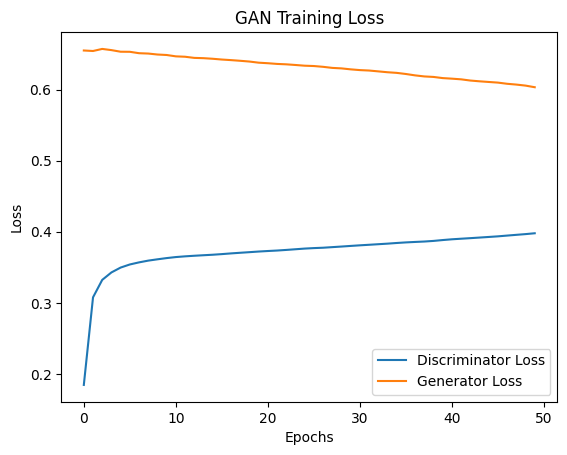

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

import tensorflow as tf
from tensorflow.keras import layers, models

# ---------------- CREATE FOLDER ----------------
if not os.path.exists("models"):
    os.makedirs("models")

# ---------------- LOAD DATA ----------------
df = pd.read_csv("transactions.csv")
df['isFraud'] = df['isFraud'].astype(int)

# ---------------- FEATURES ----------------
X = df[['amount']].values
y = df['isFraud'].values

# ---------------- SPLIT ----------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ---------------- USE ONLY NORMAL DATA FOR GAN ----------------
X_train_normal = X_train[y_train == 0]

# ---------------- GAN PARAMETERS ----------------
latent_dim = 10

# ---------------- GENERATOR ----------------
def build_generator():
    model = models.Sequential([
        layers.Dense(16, activation='relu', input_dim=latent_dim),
        layers.Dense(32, activation='relu'),
        layers.Dense(1)  # output = amount
    ])
    return model

# ---------------- DISCRIMINATOR ----------------
def build_discriminator():
    model = models.Sequential([
        layers.Dense(32, activation='relu', input_dim=1),
        layers.Dense(16, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# ---------------- BUILD MODELS ----------------
generator = build_generator()
discriminator = build_discriminator()

# Freeze discriminator for GAN training
discriminator.trainable = False

# GAN MODEL
gan_input = layers.Input(shape=(latent_dim,))
fake_data = generator(gan_input)
gan_output = discriminator(fake_data)

gan = models.Model(gan_input, gan_output)
gan.compile(optimizer='adam', loss='binary_crossentropy')

# ---------------- TRAIN GAN ----------------
epochs = 50
batch_size = 32

d_losses = []
g_losses = []

for epoch in range(epochs):
    # Train Discriminator
    idx = np.random.randint(0, X_train_normal.shape[0], batch_size)
    real_data = X_train_normal[idx]

    noise = np.random.normal(0, 1, (batch_size, latent_dim))
    fake_data = generator.predict(noise, verbose=0)

    real_labels = np.ones((batch_size, 1))
    fake_labels = np.zeros((batch_size, 1))

    d_loss_real = discriminator.train_on_batch(real_data, real_labels)
    d_loss_fake = discriminator.train_on_batch(fake_data, fake_labels)

    d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)

    # Train Generator
    noise = np.random.normal(0, 1, (batch_size, latent_dim))
    g_loss = gan.train_on_batch(noise, real_labels)

    d_losses.append(d_loss[0])
    g_losses.append(g_loss)

    if epoch % 5 == 0:
        print(f"Epoch {epoch} | D Loss: {d_loss[0]:.4f} | G Loss: {g_loss:.4f}")

# ---------------- ANOMALY DETECTION ----------------
# Use discriminator output as anomaly score
y_pred_probs = discriminator.predict(X_test)
y_pred = (y_pred_probs < 0.5).astype(int)  # low prob = fraud

# ---------------- ACCURACY ----------------
accuracy = accuracy_score(y_test, y_pred)
print(f"\n✅ Accuracy: {accuracy * 100:.2f}%")

# ---------------- SAVE MODELS ----------------
generator.save("models/generator.h5")
discriminator.save("models/discriminator.h5")

print("✅ GAN models saved!")

# ---------------- LOSS GRAPH ----------------
plt.figure()
plt.plot(d_losses, label="Discriminator Loss")
plt.plot(g_losses, label="Generator Loss")
plt.title("GAN Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()